In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
import rasterio
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import zipfile
import shutil
import datetime
import os, sys
sys.path.append('../../src/actual_et_usgs')

from process_actual_et_usgs import *


DATA_DIR = "/Users/jgomezvelez/Downloads/2000/det2000366.modisSSEBopETactual"

filename = 'det2000366.modisSSEBopETactual.tif'

In [13]:
DATA_DIR = "/Users/jgomezvelez/Downloads"
filenames_zips = ['2000.zip']

process_actual_et_zip_files(filenames_level_0 = filenames_zips, data_dir = DATA_DIR)

Done wirh file 2000.zip


In [14]:
data = xr.open_dataset(os.path.join(DATA_DIR, '2000_clipped_iowa.nc'))
data

<xarray.Dataset> Size: 1GB
Dimensions:           (date: 732, y: 586, x: 838)
Coordinates:
  * x                 (x) float64 7kB -98.03 -98.02 -98.01 ... -89.96 -89.95
  * y                 (y) float64 5kB 45.82 45.81 45.8 ... 40.19 40.19 40.18
    spatial_ref       int64 8B ...
  * date              (date) datetime64[ns] 6kB 2000-01-01 ... 2000-12-31
Data variables:
    actual_et_mm_day  (date, y, x) float32 1GB ...

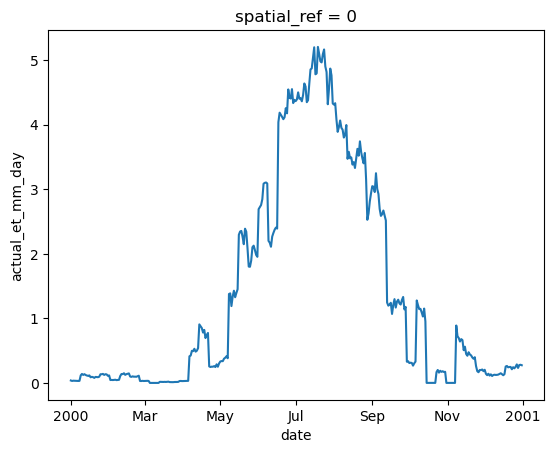

In [15]:
data.actual_et_mm_day.mean(dim=["x", "y"]).plot()

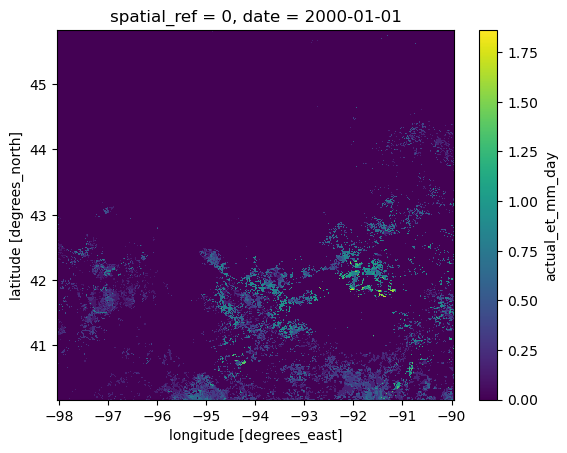

In [9]:
data.actual_et_mm_day.isel(date=0).plot()

'2000001'

# Box for Iowa

In [ ]:
# Create a bounding box polygon
lat_min, lat_max, lon_min, lon_max = 40.17, 45.83, -98.04, -89.95

# Create a bounding box polygon
bbox = gpd.GeoDataFrame({
    'geometry': [box(lon_min, lat_min, lon_max, lat_max)]
}, crs="EPSG:4326")

# Read data

In [ ]:
# def read_tiff_data(filename, data_dir):

#     data = rioxarray.open_rasterio(os.path.join(data_dir, filename))
#     nodata = data.rio.nodata

#     # Mask nodata values before dividing
#     data_masked = data.where(data != nodata)
#     data_scaled = data_masked / 1000

#     # Fill back nodata where it was masked
#     data_scaled = data_scaled.where(~data_masked.isnull(), other=nodata)
#     data_scaled.rio.write_nodata(nodata, inplace=True)

#     data = data_scaled

#     return data

In [ ]:
data = read_tiff_data(filename, DATA_DIR)
# Clip data to the bounding box
data_clipped = data.rio.clip(bbox.geometry, bbox.crs, drop=True)

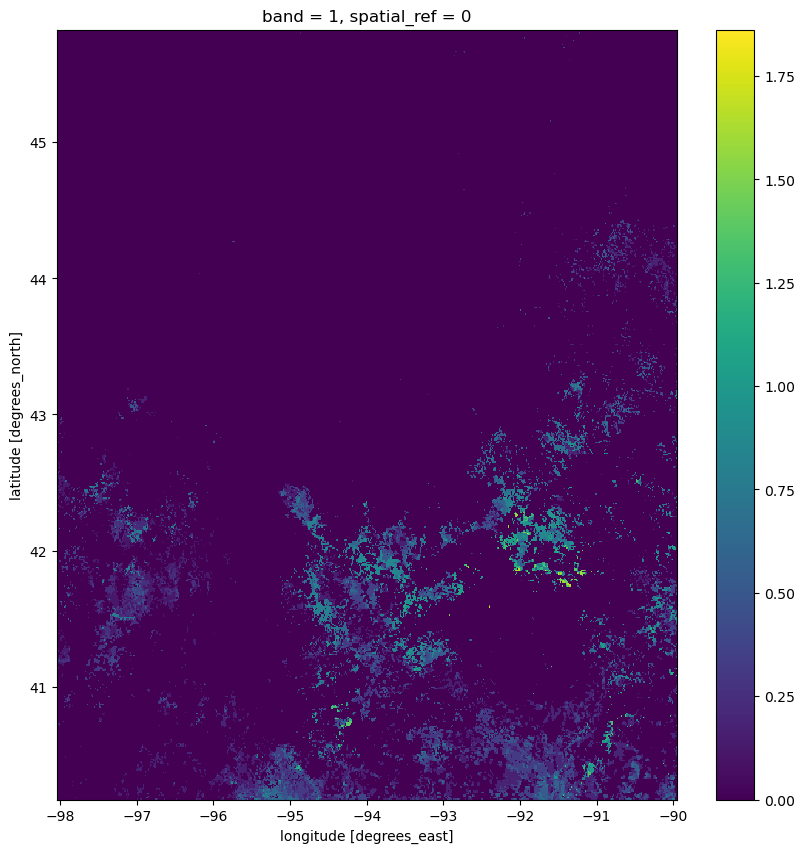

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
# data.where(data != data.rio.nodata).plot(ax=ax)
data.where(data != data.rio.nodata).plot(ax=ax)
# bbox.boundary.plot(ax=ax, color='red', linewidth=2)
